U# Vehicle Helmet Detection CNN Model Training Pipeline
- Ingests source dataset with annotated bounding boxes
- Extracts individual objects using provided bounding boxes
- Normalizes samples by cropping and resizing to 100×100 with centered subjects
- Constructs a cleaned, single-subject image dataset for training
- Trains a CNN classifier (VGG16 transfer learning) on curated data

In [2]:
import shutil
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


### Load Data from Original Dataset

Source: https://www.kaggle.com/datasets/andrewmvd/helmet-detection
Author: Larxel (andrewmvd)

Bounding box annotations are provided in the PASCAL VOC format
The classes are:
With helmet;
Without helmet.

In [3]:
# Dataset settings
DATA_DIR = "/kaggle/input/andrewmvd/helmet-detection"
CLASS_NAMES = ["With Helmet", "Without Helmet"]
CLASS_DIRECTORY = ["with_helmet", "without_helmet"]
NUM_CLASSES = 2
# Image settings
CROPPED_SIZE = 100
IMAGE_CHANNELS = 3

In [4]:
import kagglehub

# Path to Kaggle Helmet Dataset
path = kagglehub.dataset_download("andrewmvd/helmet-detection")
path_annotations = path+'/annotations'
path_images = path+'/images'
print(path)

/Users/daniel/Projects/HelmNet_Data_Source_Comparisions/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/daniel/.cache/kagglehub/datasets/andrewmvd/helmet-detection/versions/1


## Splitting Dataset
- Cropping images to 100x100 using predefined bounding boxes from source data.
- Holding out some test data at the file system level for later use

In [5]:
import random
import os

full_annotation_set = os.listdir(path_annotations)
train_files = full_annotation_set[:int(len(full_annotation_set) * 0.9)]
test_files = full_annotation_set[int(len(full_annotation_set) * 0.9):]

In [6]:
# Clean output directory
CROPPED_SIZE = 100
MIN_SIZE_CROPPED = 50
DATASET_2_OUTPUT = "data/dataset2"
DATASET_2_TEST_OUTPUT = "data/dataset2_test"

CLASS_DIRECTORY = ["with_helmet", "without_helmet"]
DATASETS = [DATASET_2_OUTPUT, DATASET_2_TEST_OUTPUT]
for dataset in DATASETS:
    if os.path.exists(dataset):
        shutil.rmtree(dataset)
    os.makedirs(dataset)
    for class_name in CLASS_DIRECTORY:
        class_directory = os.path.join(dataset, class_name)
        os.makedirs(class_directory)


In [7]:
import os
import cv2
import pandas as pd
import xml.etree.ElementTree as ET

# Function to parse bounding boxes from PASCAL VOC XML files into a dataframe
def parse_voc_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    bboxes = []
    for obj in root.findall('object'):
        bbox = obj.find('bndbox')
        x_min = int(bbox.find('xmin').text)
        y_min = int(bbox.find('ymin').text)
        x_max = int(bbox.find('xmax').text)
        y_max = int(bbox.find('ymax').text)
        class_name = obj.find('name').text
        bboxes.append({'x_min': x_min, 'y_min': y_min, 'x_max': x_max, 'y_max': y_max, 'class': class_name})
    return pd.DataFrame(bboxes)

def generate_cropped_images(annotation_set, output_dir):
    print(f"Generating cropped images for {len(annotation_set)} files...")
    # Crop images based on annotations in dataframe
    for annotation_file in annotation_set:
        if annotation_file.endswith('.xml'):
            image_id = os.path.splitext(annotation_file)[0]
            image_path = os.path.join(path_images, image_id + '.png')
            # print(f"Processing {annotation_file} for image {image_id}...")
            annotation_file = os.path.join(path_annotations, annotation_file)
            if os.path.exists(annotation_file):
                # print(f"Loading image {image_id} from {image_path}...")
                if os.path.exists(image_path): # Check if the image was loaded successfully
                    image = cv2.imread(image_path)
                    bboxes_df = parse_voc_annotation(annotation_file)

                    for i, row in bboxes_df.iterrows():
                        if row['x_max'] - row['x_min'] > MIN_SIZE_CROPPED and row['y_max'] - row['y_min'] > MIN_SIZE_CROPPED:
                            x_min, y_min, x_max, y_max, class_name = row['x_min'], row['y_min'], row['x_max'], row['y_max'], \
                            row['class']
                            # Calculate the center of a cropped image.
                            x_center = (x_min + x_max) // 2
                            y_center = (y_min + y_max) // 2
                            # Calculate min_x, and min_y based on center
                            x_min_modified = x_center - CROPPED_SIZE // 2
                            y_min_modified = y_center - CROPPED_SIZE // 2
                            x_min = max(x_min_modified, 0)
                            y_min = max(y_min_modified, 0)
                            # Set x_max and y_max based on x_min, and y_min
                            x_max_modified = x_min + CROPPED_SIZE
                            y_max_modified = y_min + CROPPED_SIZE
                            x_max = min(x_max_modified, image.shape[1])
                            y_max = min(y_max_modified, image.shape[0])
                            # Adjust min_x, and min_y a second time to account for images near the edge of the original image.
                            x_min = x_max - CROPPED_SIZE if x_min < 0 else x_min
                            y_min = y_max - CROPPED_SIZE if y_min < 0 else y_min
                            # print(f"Cropping image {image_id} with bounding box ({x_min}, {y_min}, {x_max}, {y_max})")
                            cropped_image = image[y_min:y_max, x_min:x_max]
                            if x_min > image.shape[1] or y_min > image.shape[0]:
                                print(f"Warning: Cropped image {image_id} is out of bounds. {image.shape} at ({x_min}, {y_min}) to ({x_max}, {y_max}), centered on ({x_center}, {y_center})")
                                continue
                            if class_name == "With Helmet":
                                class_directory = f"{output_dir}/with_helmet"
                                output_image_path = os.path.join(class_directory, f"{image_id}_cropped_{i}.png")
                                cv2.imwrite(output_image_path, cropped_image)
                            elif class_name == "Without Helmet":
                                class_directory = f"{output_dir}/without_helmet"
                                output_image_path = os.path.join(class_directory, f"{image_id}_cropped_{i}.png")
                                cv2.imwrite(output_image_path, cropped_image)
                else:
                    print(f"Warning: Unable to load image {image_path}. Skipping.")
generate_cropped_images(annotation_set=train_files, output_dir=DATASET_2_OUTPUT)
generate_cropped_images(annotation_set=test_files, output_dir=DATASET_2_TEST_OUTPUT)

Generating cropped images for 687 files...
Generating cropped images for 77 files...


In [8]:

from PIL import Image
import numpy as np
def load_image_paths_to_df(root_dir, image_size=(CROPPED_SIZE, CROPPED_SIZE)):
    data = []

    for label in os.listdir(root_dir):
        label_path = os.path.join(root_dir, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(label_path, file)

                    img = Image.open(file_path).convert("RGB")
                    img = img.resize(image_size)
                    img_array = np.array(img)

                    data.append({
                        "label": label,
                        "file_path": file_path
                    })

    df = pd.DataFrame(data)
    return df

dataset2_file_paths = load_image_paths_to_df(DATASET_2_OUTPUT)
test_df = load_image_paths_to_df(DATASET_2_TEST_OUTPUT)


In [9]:
pd.set_option('future.no_silent_downcasting', True)
dataset2_file_paths["label_enum"] = dataset2_file_paths["label"].replace({"with_helmet": 1, "without_helmet" : 0})
test_df["label_enum"] = test_df["label"].replace({"with_helmet": 1, "without_helmet" : 0})

## Dataset Distribution

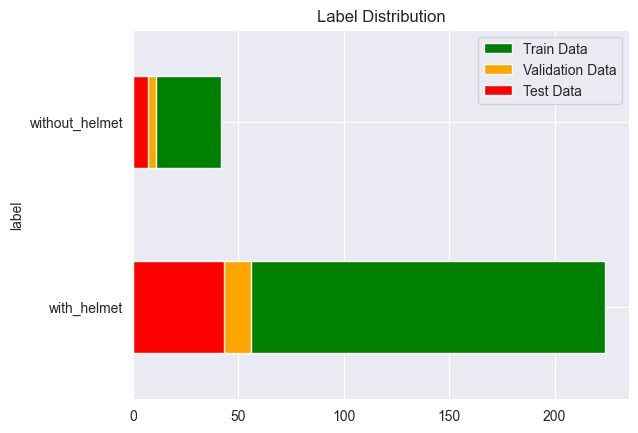

In [10]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(dataset2_file_paths, test_size=0.2, stratify=dataset2_file_paths['label_enum'], random_state=42)
from matplotlib import pyplot as plt

train_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='green', label='Train Data')
val_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='orange', label='Validation Data')
test_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='red', label='Test Data')
plt.legend();

In [11]:
import tensorflow as tf
def convert_to_tf_dataset(df):
    images = []
    labels = []
    for index, row in df.iterrows():
        file_path = row["file_path"]
        label = row["label_enum"]
        if os.path.exists(file_path):
            image = Image.open(file_path).convert("RGB")
            image = image.resize((CROPPED_SIZE, CROPPED_SIZE))
            image = np.array(image).astype('float32')
            images.append(image)
            labels.append(label)
        else:
            print(f"File not found: {file_path}")
    images = np.array(images)
    labels = np.array(labels)
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda x, y: (tf.image.per_image_standardization(x), y)).batch(32)
    return dataset


# Convert train_df and test_df to TensorFlow datasets
train_ds = convert_to_tf_dataset(train_df)
val_ds = convert_to_tf_dataset(val_df)

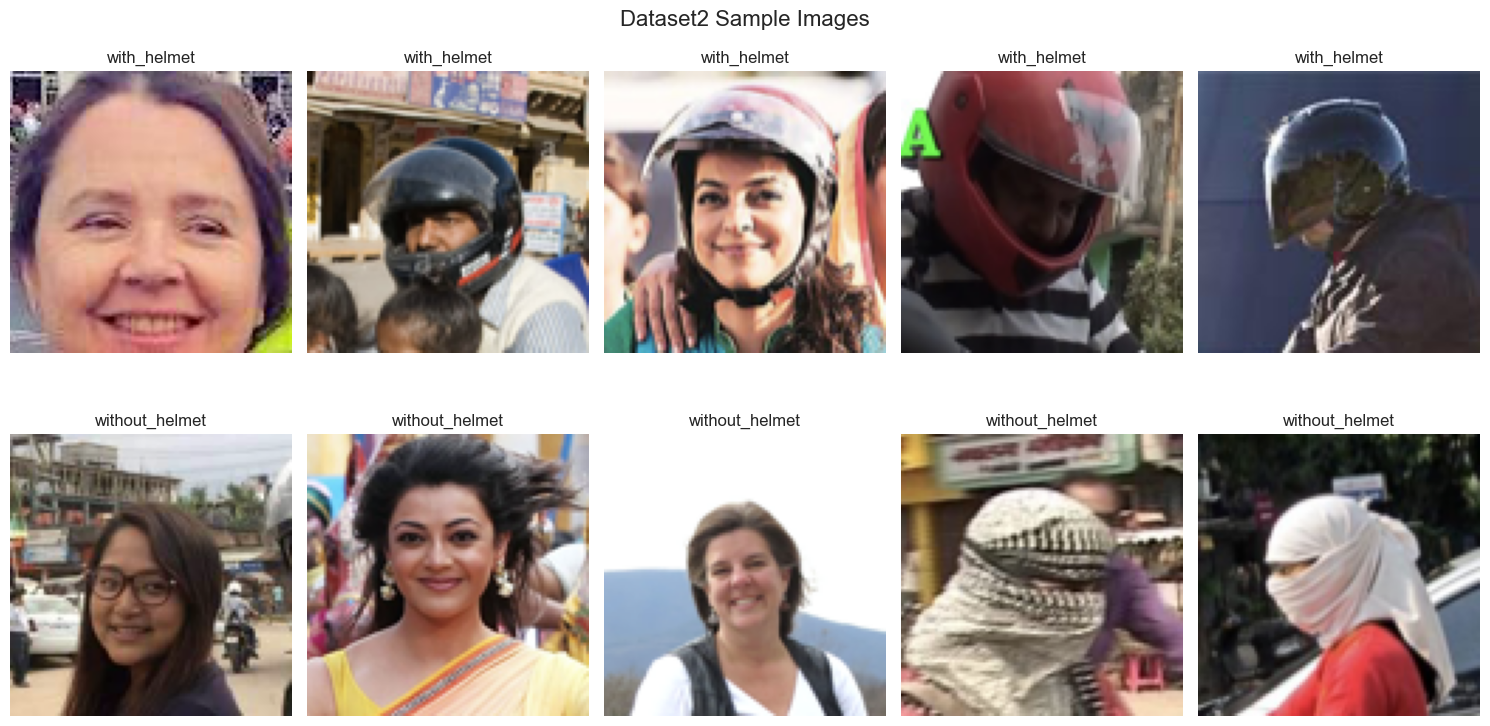

In [12]:
# Display 5 random images from each class
def display_random_images(dataframe, num_images=5, figure_name="dataset2_random_samples.png"):
    # Group by labels
    grouped = dataframe.groupby("label")
    num_classes = len(grouped)

    fig, axes = plt.subplots(
        nrows=num_classes,
        ncols=num_images,
        figsize=(15, 4 * num_classes)
    )
    axes = axes if num_classes > 1 else [axes]  # Handle single row case correctly

    for (label, group), ax_row in zip(grouped, axes):
        sampled_group = group.sample(n=min(num_images, len(group)), random_state=42)
        for i, (_, row) in enumerate(sampled_group.iterrows()):
            img = Image.open(row["file_path"]).convert("RGB")
            ax_row[i].imshow(img)
            ax_row[i].axis("off")
            ax_row[i].set_title(label, fontsize=12)
    plt.tight_layout()
    plt.suptitle("Dataset2 Sample Images", fontsize=16)
    plt.savefig("charts/" + figure_name, bbox_inches="tight")
    plt.show()
display_random_images(train_df, num_images=5, figure_name="dataset2_sample_images.png")

### Observations
- The overall quality of this dataset looks good, but it's a bit of a small sample size.
- I really appreciate the fact that this dataset contains samples with different kinds of headgear other than helmets. 
- Because the data was generated from bounding boxes some of the samples may contain parts of other features on them. 

## Run CNN on cropped images

In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

# Load VGG16 base (no top classifier)
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(CROPPED_SIZE, CROPPED_SIZE, 3)  # adjust if needed
)

# Freeze base layers
for layer in vgg_base.layers:
    layer.trainable = False

# Custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(100, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)  # binary classification

# Final model
model_2 = Model(inputs=vgg_base.input, outputs=output)
model_2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [14]:
history_2 = model_2.fit(train_ds, validation_data=val_ds, epochs=10, batch_size=32)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 434ms/step - accuracy: 0.6316 - loss: 0.6643 - val_accuracy: 0.8358 - val_loss: 0.5071
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 430ms/step - accuracy: 0.8421 - loss: 0.5378 - val_accuracy: 0.8358 - val_loss: 0.4865
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 430ms/step - accuracy: 0.8421 - loss: 0.4419 - val_accuracy: 0.8358 - val_loss: 0.4046
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 440ms/step - accuracy: 0.8383 - loss: 0.3792 - val_accuracy: 0.8358 - val_loss: 0.3779
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 452ms/step - accuracy: 0.8421 - loss: 0.3597 - val_accuracy: 0.8358 - val_loss: 0.3576
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 454ms/step - accuracy: 0.8496 - loss: 0.3465 - val_accuracy: 0.8358 - val_loss: 0.3415
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 468ms/step - accuracy: 0.8609 - loss: 0.3207 - val_accuracy: 0.8507 - val_loss: 0.3199
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 462ms/step - accuracy: 0.8684 - loss: 0.2814 - val_accuracy: 0.8657 - val_loss:

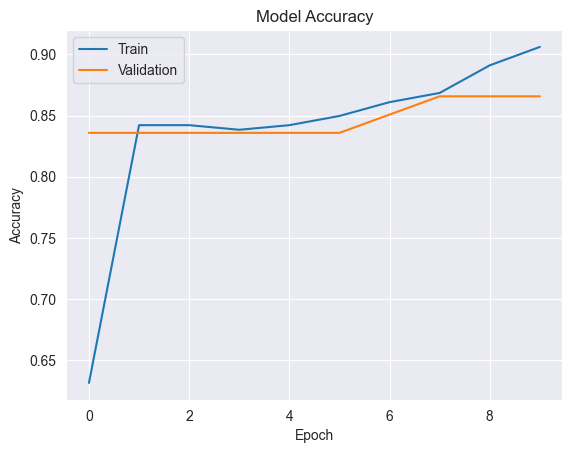

In [15]:
def plot_history(history):
    # Plot training & validation accuracy values
    plt.plot(history.history.get('accuracy', []))  # Fix: added .get() to handle missing keys
    plt.plot(history.history.get('val_accuracy', []))  # Fix: added .get() to handle missing keys
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')  # Uncommented ylabel
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

plot_history(history_2)


In [16]:
# Assuming validation dataset (val_ds) results and true labels
val_images, val_labels = zip(*[(x.numpy(), y.numpy()) for x, y in val_ds.unbatch()])  # Unbatch validation data
val_images = np.array(val_images)
val_labels = np.array(val_labels)

# Generate predictions for validation dataset
val_predictions = (model_2.predict(val_images) > 0.5).astype(int)

# Assuming test dataset (test_df) results and true labels 
test_images, test_labels = zip(*[
    (np.array(Image.open(row["file_path"]).resize((CROPPED_SIZE, CROPPED_SIZE))).astype('float32'), row["label_enum"])
    for _, row in test_df.iterrows()
])
test_images = np.array(test_images)
test_labels = np.array(test_labels)

# Generate predictions for test dataset
test_predictions = (model_2.predict(test_images) > 0.5).astype(int)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step


In [17]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

# Calculate accuracy, precision, and recall
accuracy_val = accuracy_score(val_labels, val_predictions)
precision_val = precision_score(val_labels, val_predictions)
recall_val = recall_score(val_labels, val_predictions)
f1_score_val = f1_score(val_labels, val_predictions)

accuracy_test = accuracy_score(test_labels, test_predictions)
precision_test = precision_score(test_labels, test_predictions)
recall_test = recall_score(test_labels, test_predictions)
f1_score_test = f1_score(test_labels, test_predictions)
# Create a dataframe to display the metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Validation": [accuracy_val, precision_val, recall_val, f1_score_val],
    "Test": [accuracy_test, precision_test, recall_test, f1_score_test]
})

In [18]:
model_2.save("model/HelmNet_Image_Classification.v2.h5")

In [78]:
metrics_df.to_csv("metrics/model2_metrics.csv")
metrics_df.head()

,Metric,Validation,Test
0,Accuracy,0.865672,0.880000
1,Precision,0.861538,0.877551
2,Recall,1.000000,1.000000
3,F1 Score,0.925620,0.934783


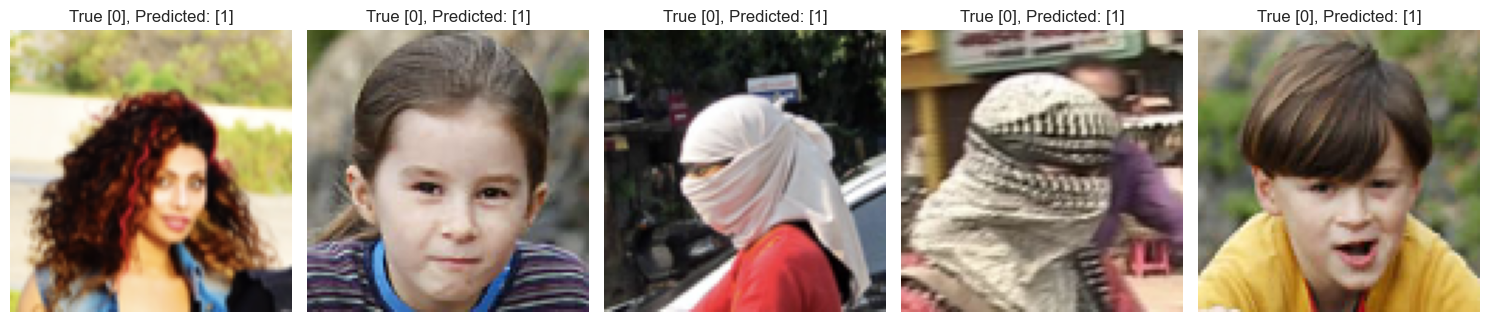

In [77]:
# Display random incorrectly categorized images
from sklearn.metrics import confusion_matrix
import random

# Confusion matrix to find misclassified images
cm = confusion_matrix(test_labels, test_predictions)
false_categorizations = [
    i for i in range(len(test_labels)) if test_labels[i] !=  test_predictions[i]
]

if false_categorizations:
    sampled_indices = random.sample(false_categorizations, min(5, len(false_categorizations)))
    plt.figure(figsize=(15, 5))
    for idx, random_index in enumerate(sampled_indices):
        misclassified_image_path = test_df.iloc[random_index]["file_path"]
        misclassified_image = np.array(Image.open(misclassified_image_path).convert("RGB"))
        plt.subplot(1, 5, idx + 1)
        plt.imshow(misclassified_image)
        plt.title(f"True [{test_labels[random_index]}], Predicted: {test_predictions[random_index]}")
        plt.axis("off")
    plt.tight_layout()

    plt.savefig("charts/model2_misclassified_images.png", bbox_inches="tight")
    plt.show()
else:
    print("No misclassified 'With Helmet' images found.")


# Dataset2 Summary
- Model2 has a high Recall score but a lower precision and accuracy score.
- Several of these falsely categorized images contain non-helmet headcoverings which could explain these results.
- This dataset contains ~250 images and has more samples with helmets than without.
- This training dataset was generated from bounding box data in a vehicle helmet dataset.
- All images are cropped at exactly 100x100 pixels, and samples with features smaller than 50 px are removed from the dataset.